# Exploratory Data Analysis

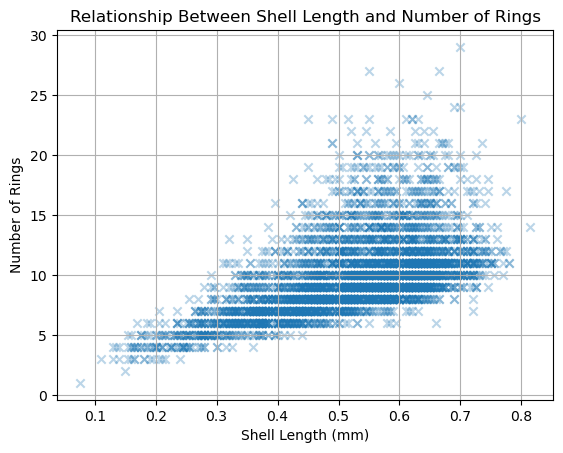

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "turtle-2.csv"
df = pd.read_csv(file_path)

## Assign features (X) and (y)
y = df['Rings']
X = df.drop(columns=['Rings'])

numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.drop('Rings')

# Creating scatter plots for each measurement against Rings
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature], df['Rings'], alpha=0.3, marker='x')
    plt.xlabel(feature)
    plt.ylabel("Number of Rings")
    plt.title(f"Relationship Between {feature} and Number of Rings")
    plt.grid(True)
    plt.show()


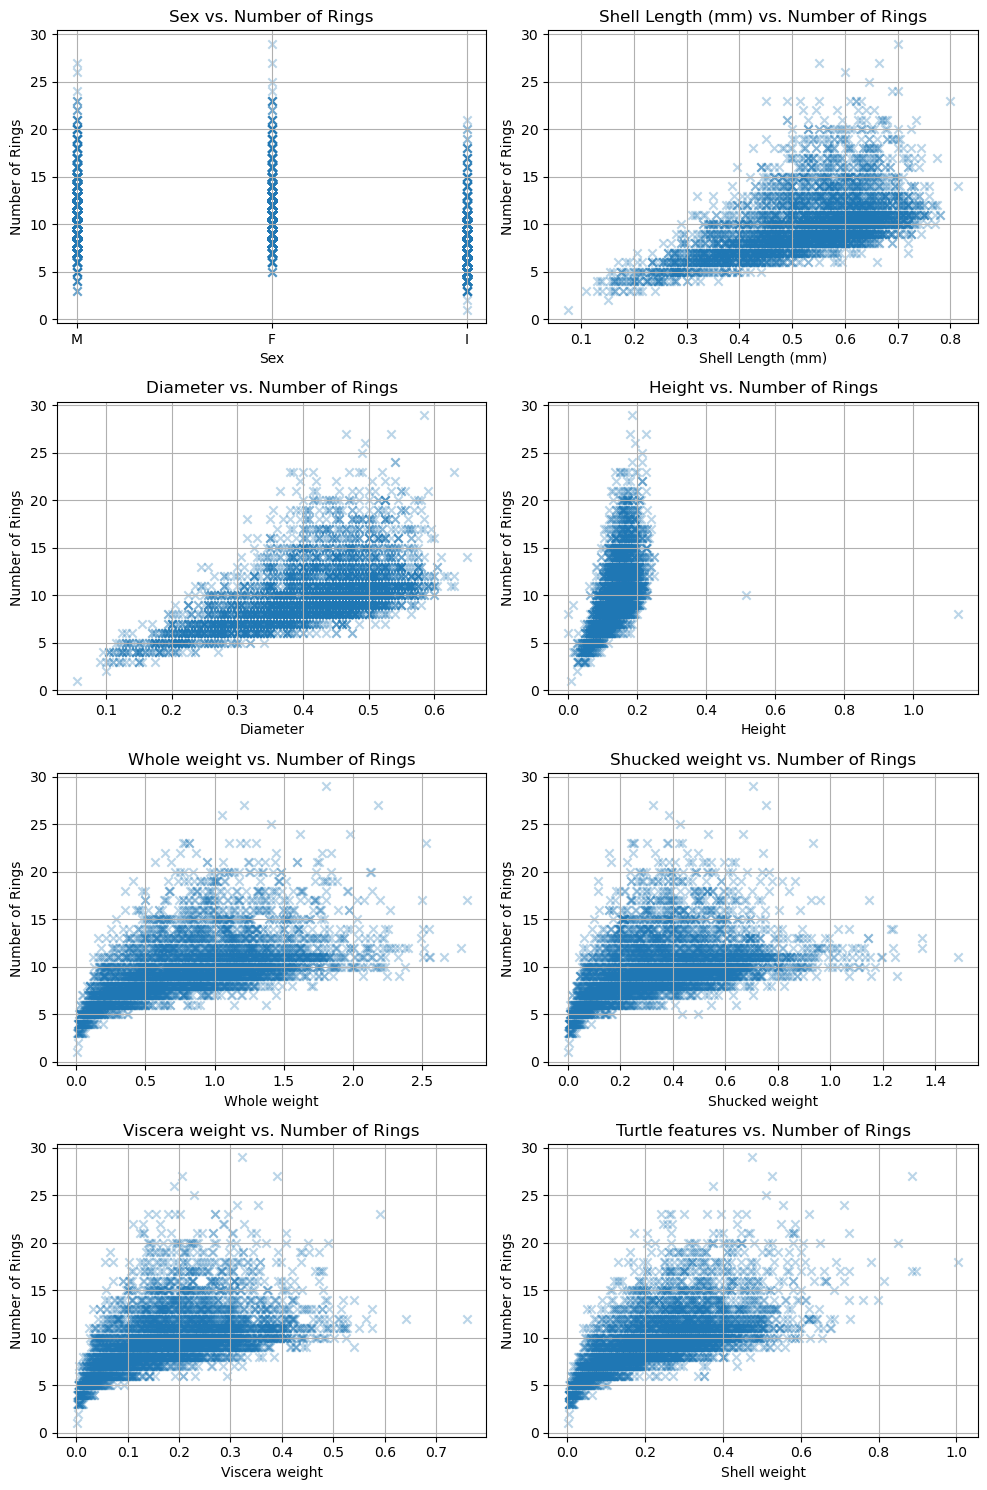

In [ ]:
# More scatterplots for my own visualization

rows, cols = (4, 2)
fig, axes = plt.subplots(rows, cols, figsize=(10,15))
axes = axes.flatten()

# Generate scatter plots for each numerical feature
for ax, feature in zip(axes, X):
    ax.scatter(df[feature], df['Rings'], alpha=0.3, marker='x')
    if feature == "Length":
        feature = "Shell Length (mm)"
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Rings")
    ax.set_title(f"{feature} vs. Number of Rings")
    ax.grid(True)

plt.title("Turtle features vs. Number of Rings")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


## Summary Statistics and Correlations

In [85]:
# Basic descriptive statistics

desc_stats = df.describe().loc[['mean', 'std', 'min', 'max']]
print("Descriptive Statistics:\n", desc_stats)


latex_table = df.describe().to_latex(float_format="%.3f", caption="Descriptive Statistics", label="tab:desc_stats")
print(latex_table)  # Copy-paste into your paper


Descriptive Statistics:
         Length  Diameter    Height  Whole weight  Shucked weight  \
mean  0.523992  0.407881  0.139516      0.828742        0.359367   
std   0.120093  0.099240  0.041827      0.490389        0.221963   
min   0.075000  0.055000  0.000000      0.002000        0.001000   
max   0.815000  0.650000  1.130000      2.825500        1.488000   

      Viscera weight  Shell weight      Rings  
mean        0.180594      0.238831   9.933684  
std         0.109614      0.139203   3.224169  
min         0.000500      0.001500   1.000000  
max         0.760000      1.005000  29.000000  
\begin{table}
\caption{Descriptive Statistics}
\label{tab:desc_stats}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Length & Diameter & Height & Whole weight & Shucked weight & Viscera weight & Shell weight & Rings \\
\midrule
count & 4177.000 & 4177.000 & 4177.000 & 4177.000 & 4177.000 & 4177.000 & 4177.000 & 4177.000 \\
mean & 0.524 & 0.408 & 0.140 & 0.829 & 0.359 & 0.181 & 0.239 & 9.934 \\
std &

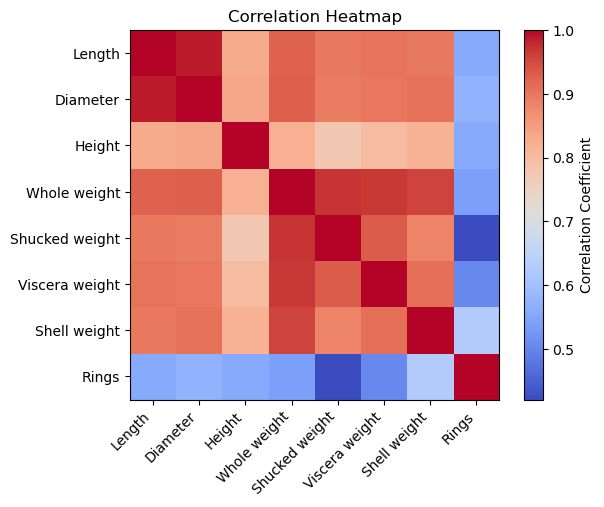

In [24]:
import numpy as np

# Correlation heatmap
correlation_matrix = df.drop(columns=['Sex']).corr()
plt.figure()
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlation Coefficient")
plt.xticks(ticks=np.arange(len(correlation_matrix.columns)), labels=correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(correlation_matrix.columns)), labels=correlation_matrix.columns)
plt.title("Correlation Heatmap")
plt.show()

In [47]:
# Correlations sorted by strength
correlation_matrix['Rings'].sort_values(ascending=False)

Rings             1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Name: Rings, dtype: float64

# Influence of Gender

/var/folders/gl/k4lymyds459_r2rf7dsm8hm80000gn/T/ipykernel_95446/3301494410.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rings_by_sex, labels=sex_categories)


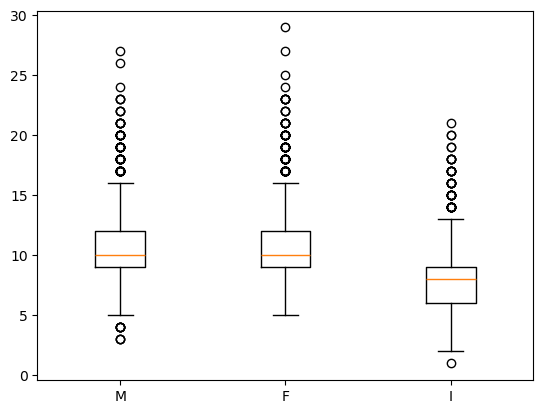

In [53]:
# Influence of gender on rings

sex_categories = df['Sex'].unique()
rings_by_sex = [df[df['Sex'] == sex]['Rings'] for sex in sex_categories]

plt.figure()
plt.boxplot(rings_by_sex, labels=sex_categories)
plt.show()

In [55]:
# Basic statistics

stats_by_sex = {
    sex: {
        "Mean": np.mean(rings),
        "Median": np.median(rings),
        "Standard Deviation": np.std(rings, ddof=1),
        "Min": np.min(rings),
        "Max": np.max(rings),
        "Q1 (25th Percentile)": np.percentile(rings, 25),
        "Q3 (75th Percentile)": np.percentile(rings, 75),
        "IQR (Q3 - Q1)": np.percentile(rings, 75) - np.percentile(rings, 25)
    }
    for sex, rings in zip(sex_categories, rings_by_sex)
}

stats_df = pd.DataFrame(stats_by_sex).T
display(stats_df)

,Mean,Median,Standard Deviation,Min,Max,Q1 (25th Percentile),Q3 (75th Percentile),IQR (Q3 - Q1)
M,10.705497,10.0,3.026349,3.0,27.0,9.0,12.0,3.0
F,11.129304,10.0,3.104256,5.0,29.0,9.0,12.0,3.0
I,7.890462,8.0,2.511554,1.0,21.0,6.0,9.0,3.0


In [ ]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(df[df['Sex'] == 'M']['Rings'], 
                           df[df['Sex'] == 'F']['Rings'],
                           df[df['Sex'] == 'I']['Rings'])
print("F-statistic:", f_stat, "p-value:", p_value)

F-statistic: 499.33254468883234 p-value: 3.724620497195191e-195


In [57]:
from itertools import combinations
from scipy.stats import ttest_ind

# Get all possible pairs of Sex categories
sex_pairs = list(combinations(sex_categories, 2))

# Pairwise t-tests
pairwise_results = {}
for sex1, sex2 in sex_pairs:
    t_stat, p_value = ttest_ind(df[df['Sex'] == sex1]['Rings'], 
                                df[df['Sex'] == sex2]['Rings'], 
                                equal_var=False)  # Welch’s t-test for unequal variance
    pairwise_results[f"{sex1} vs {sex2}"] = {"t-statistic": t_stat, "p-value": p_value}

pairwise_df = pd.DataFrame(pairwise_results).T
display(pairwise_df)


,t-statistic,p-value
M vs F,-3.665660,2.513813e-04
M vs I,27.221165,2.765560e-145
F vs I,29.476561,3.080725e-164


In [61]:
def cohens_d(group1, group2):
    return (np.mean(group1) - np.mean(group2)) / ((np.std(group1, ddof=1) + np.std(group2, ddof=1)) / 2)

from itertools import combinations

effect_sizes = {f"{s1} vs {s2}": cohens_d(df[df['Sex'] == s1]['Rings'], df[df['Sex'] == s2]['Rings']) 
                for s1, s2 in combinations(df['Sex'].unique(), 2)}

display(effect_sizes)

{'M vs F': -0.13825921457515042,
 'M vs I': 1.016643017623053,
 'F vs I': 1.1534726581364059}

The statistics show that gender has a strong influence on the the number of rings on a trutle.

## Regression